# Phase 8: Unified adaptation controller

This notebook reads completed immutable artifacts only. Schema-v7 through schema-v10 runs use one predictable $\pi_t$ for both Fisher-summary blending and mixture-weighted EWC. Schema v8 adds adaptive oracle confidence radii; schema v9 repairs the normalized-drift covariance estimator; schema v10 records L-BFGS compute budgets and actual optimizer work. Historical decoupled runs are shown separately and are never pooled with the principal conditions.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

start = Path.cwd().resolve()
candidates = (start, *start.parents)
REPO_ROOT = next((path for path in candidates if (path / 'mnist_experiment' / 'AGENTS.md').is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not locate the repository root from the current working directory.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.results_analysis import (
    AnalysisArtifactError,
    discover_phase7_runs,
    discover_phase8_controller_runs,
    phase7_coupled_rows,
    phase7_coupled_summaries,
    phase8_controller_rows,
    phase8_controller_summaries,
)

PHASE8_ROOT = REPO_ROOT / 'cache' / 'mnist_experiment' / 'phase8_runs'
PHASE7_ROOT = REPO_ROOT / 'cache' / 'mnist_experiment' / 'phase7_runs'
phase8_runs = discover_phase8_controller_runs(PHASE8_ROOT)
rows = phase8_controller_rows(phase8_runs)
summary = pd.DataFrame(phase8_controller_summaries(rows))
flat = pd.json_normalize(rows, sep='_')


## Run inventory

In [10]:
inventory = pd.DataFrame([
    {
        'run_id': run.run_id,
        'replica': run.config.replica_id,
        'policy': run.metrics['policy'],
        'metric_schema': run.metrics['phase8_metric_schema_version'],
        'optimizer': run.config.optimizer.name,
        'iteration_budget': run.config.optimizer.inner_steps,
        'controller_methods': ', '.join(run.config.estimator.controller_methods or ['dense', 'diagonal', 'low_rank_diagonal']),
        'steps': len(run.p_values),
        'samples_per_step': run.config.data.samples_per_step,
        'reference_sample_size': run.config.reference.sample_size,
        'oracle_fit_sample_size': run.config.reference.calibration_steps * run.config.reference.calibration_batch_size,
        'oracle_path_hash': run.metrics['oracle_path_hash'],
    }
    for run in phase8_runs
])
display(inventory)
display(summary)


,run_id,replica,policy,metric_schema,optimizer,iteration_budget,controller_methods,steps,samples_per_step,reference_sample_size,oracle_fit_sample_size,oracle_path_hash
0,mnist_lfu_phase8_controller_smoke__replica-000...,replica-0000,optimal_plugin,3,sgd,2,"dense, diagonal, low_rank_diagonal",3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...
1,mnist_lfu_phase8_controller_smoke__replica-000...,replica-0000,optimal_plugin,2,sgd,2,"dense, diagonal, low_rank_diagonal",3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...
2,mnist_lfu_phase8_convergence_smoke__replica-00...,replica-0000,optimal_plugin,4,sgd,2,"dense, diagonal, low_rank_diagonal",3,2,16,8,f4e6cd12387cbe5ef5b0c1ecc44e979c2d515df3ebf14e...
3,mnist_lfu_phase8_fixed_compatibility_smoke__re...,replica-0000,fixed_unified,3,sgd,2,"dense, diagonal, low_rank_diagonal",3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...
4,mnist_lfu_phase8_fixed_compatibility_smoke__re...,replica-0000,fixed_unified,2,sgd,2,"dense, diagonal, low_rank_diagonal",3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...
5,mnist_lfu_phase8_freeze_smoke__replica-0000__3...,replica-0000,freeze,3,sgd,2,"dense, diagonal, low_rank_diagonal",3,2,16,8,1ca4fd5bcf931cd7d480db54ce9c1a94ebe29c4560fcbb...
6,mnist_lfu_phase8_gpu_convergence__replica-0000...,replica-0000,optimal_plugin,4,sgd,20,"dense, diagonal, low_rank_diagonal",100,128,32768,12800,bb88e626922d1f6b479516e09ec9db75ea7779a681c93f...
7,mnist_lfu_phase8_gpu_corrected_plugin__replica...,replica-0000,optimal_plugin,5,sgd,20,"dense, diagonal, low_rank_diagonal",100,128,32768,12800,bb88e626922d1f6b479516e09ec9db75ea7779a681c93f...
8,mnist_lfu_phase8_gpu_k100_fixed__replica-0000_...,replica-0000,fixed_unified,6,lbfgs,100,"dense, diagonal, low_rank_diagonal",100,128,32768,12800,bb88e626922d1f6b479516e09ec9db75ea7779a681c93f...
9,mnist_lfu_phase8_gpu_k100_oracle__replica-0000...,replica-0000,optimal_oracle,6,lbfgs,100,"dense, diagonal, low_rank_diagonal",100,128,32768,12800,bb88e626922d1f6b479516e09ec9db75ea7779a681c93f...


,run_id,policy,method,mean_pi,lower_bound_frequency,upper_bound_frequency,mean_fisher_error,mean_trace_relative_error,backtracking_rejections,maximum_backtracks,minimum_learning_rate,mean_optimizer_iterations,maximum_optimizer_iterations,mean_optimizer_function_evaluations,maximum_optimizer_function_evaluations,mean_relative_final_gradient_norm,maximum_relative_final_gradient_norm,mean_final_gradient_rms,final_balanced_accuracy,final_parameter_squared_error_to_oracle
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,0.050000,1.000000,0.0,1.055648,0.472884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000931
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,0.050000,1.000000,0.0,1.022017,0.473330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000932
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,0.050000,1.000000,0.0,1.067277,0.474324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000930
3,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,0.050000,1.000000,0.0,1.055648,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000931
4,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,0.050000,1.000000,0.0,1.022017,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000932
5,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,0.050000,1.000000,0.0,1.067277,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000930
6,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,dense_ridge_full,0.050000,1.000000,0.0,1.055648,0.458699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000657
7,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,diagonal_ridge_full,0.050000,1.000000,0.0,1.022017,0.459078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000658
8,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,low_rank_diagonal_r4,0.050000,1.000000,0.0,1.067277,0.460133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000657
9,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,dense_ridge_full,0.500000,0.000000,0.0,0.605017,0.476358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,0.000934


## Optimizer compute budget

The configured L-BFGS iteration count $K$ is a fixed compute budget, not a claim that a deep-net EWC objective has converged. The principal comparison uses $K=100$. Rank-8-plus-diagonal plugin runs at $K=50$ and $K=200$ measure budget sensitivity without repeating the full representation grid. Actual iterations and objective evaluations are retained because line search may stop before exhausting either limit.

In [11]:
budget_columns = [
    'run_id', 'policy', 'method',
    'mean_optimizer_iterations', 'maximum_optimizer_iterations',
    'mean_optimizer_function_evaluations',
    'maximum_optimizer_function_evaluations',
    'mean_relative_final_gradient_norm',
    'maximum_relative_final_gradient_norm',
    'mean_final_gradient_rms',
]
available_budget_columns = [column for column in budget_columns if column in summary.columns]
display(summary[available_budget_columns])


,run_id,policy,method,mean_optimizer_iterations,maximum_optimizer_iterations,mean_optimizer_function_evaluations,maximum_optimizer_function_evaluations,mean_relative_final_gradient_norm,maximum_relative_final_gradient_norm,mean_final_gradient_rms
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,low_rank_diagonal_r4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,dense_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,diagonal_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,low_rank_diagonal_r4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,mnist_lfu_phase8_fixed_compatibility_smoke__re...,fixed_unified,dense_ridge_full,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Unified versus historical fixed weights

The schema-v7 fixed condition uses $\pi=0.5$ in both recursions. The historical schema-v6 condition uses EWC $\pi=0.5$ and an independent Fisher gain $\alpha=0.25$; it is retained only as a compatibility diagnostic.

In [12]:
compatibility = []
fixed_unified = summary[summary['policy'] == 'fixed_unified'].copy()
for _, row in fixed_unified.iterrows():
    compatibility.append({
        'paradigm': 'schema-v7 unified pi=0.5',
        'method': row['method'],
        'mean_fisher_error': row['mean_fisher_error'],
        'final_balanced_accuracy': row['final_balanced_accuracy'],
    })
try:
    _, phase7_coupled = discover_phase7_runs(PHASE7_ROOT)
    legacy_runs = [
        run for run in phase7_coupled
        if run.config.controller.fixed_pi == 0.5
        and run.config.estimator.ema_gain == 0.25
        and run.config.data.num_p_steps == 3
        and run.config.data.samples_per_step == 2
    ]
    legacy_summary = phase7_coupled_summaries(phase7_coupled_rows(legacy_runs))
    for row in legacy_summary:
        compatibility.append({
            'paradigm': 'schema-v6 decoupled pi=0.5, alpha=0.25',
            'method': row['method'],
            'mean_fisher_error': row['mean_fisher_error'],
            'final_balanced_accuracy': row['final_balanced_accuracy'],
        })
except AnalysisArtifactError as error:
    display(Markdown(f'Historical compatibility artifacts unavailable: `{error}`'))
display(pd.DataFrame(compatibility))


,paradigm,method,mean_fisher_error,final_balanced_accuracy
0,schema-v7 unified pi=0.5,dense_ridge_full,0.605017,0.100000
1,schema-v7 unified pi=0.5,diagonal_ridge_full,0.777650,0.100000
2,schema-v7 unified pi=0.5,low_rank_diagonal_r4,0.674632,0.100000
3,schema-v7 unified pi=0.5,dense_ridge_full,0.605017,0.100000
4,schema-v7 unified pi=0.5,diagonal_ridge_full,0.777650,0.100000
5,schema-v7 unified pi=0.5,low_rank_diagonal_r4,0.674632,0.100000
6,schema-v7 unified pi=0.5,dense_ridge_full,0.546762,0.231274
7,schema-v7 unified pi=0.5,diagonal_ridge_full,0.975877,0.676396
8,schema-v7 unified pi=0.5,low_rank_diagonal_r8,0.653987,0.352916
9,schema-v7 unified pi=0.5,low_rank_diagonal_r8,0.598300,0.735923


## Controller trajectories

/tmp/ipykernel_214695/4263931003.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


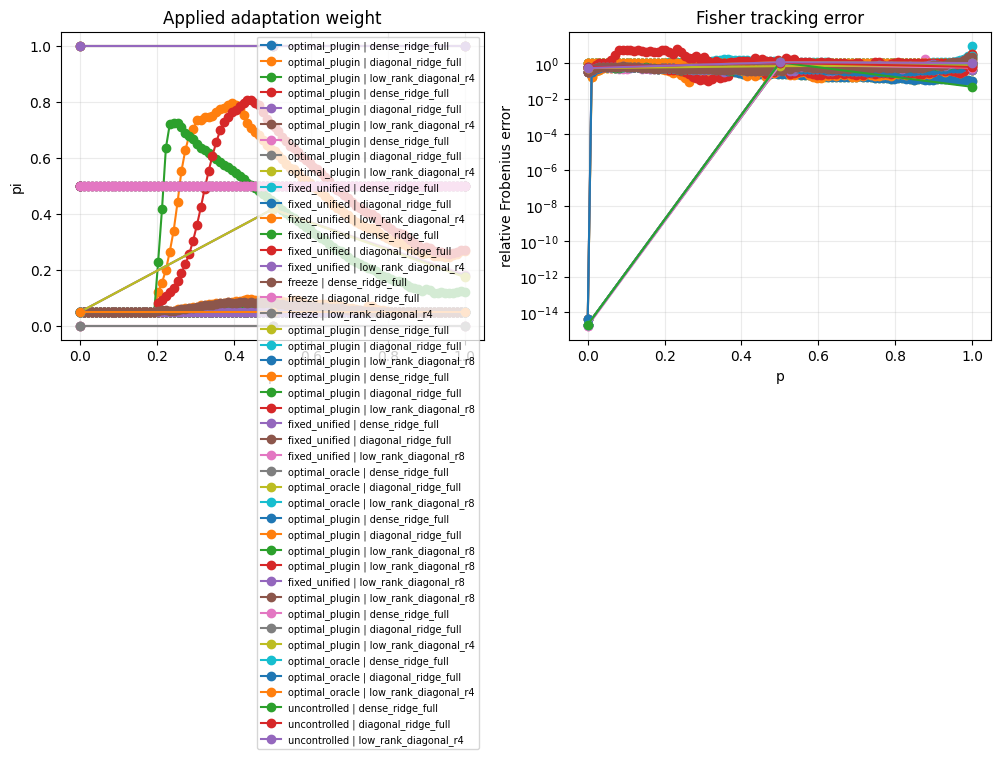

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (run_id, method), group in flat.groupby(['run_id', 'method']):
    ordered = group.sort_values('p')
    label = f"{ordered['policy'].iloc[0]} | {method}"
    axes[0].plot(ordered['p'], ordered['controller_applied_pi'], marker='o', label=label)
    axes[1].plot(ordered['p'], ordered['relative_frobenius_error'], marker='o', label=label)
axes[0].set(title='Applied adaptation weight', xlabel='p', ylabel='pi')
axes[1].set(title='Fisher tracking error', xlabel='p', ylabel='relative Frobenius error')
for axis in axes:
    axis.grid(alpha=0.25)
axes[1].set_yscale('log')
axes[0].legend(fontsize=7)
plt.tight_layout()


## Environment-weighted adaptation and retention

At mixture value $p$, the current-environment metrics are $A_{env}(p)=(1-p)A_{non9}(p)+pA_9(p)$ and $L_{env}(p)=(1-p)L_{non9}(p)+pL_9(p)$. Their normalized trapezoidal AUCs summarize the complete trajectory. Digit-9 accuracy and NLL remain explicit primary adaptation outcomes; the weighted summaries do not replace them.

In [14]:
principal_pattern = r"phase8_gpu_k50_(?:plugin|fixed)_rank8"
principal_summary = summary[summary["run_id"].str.contains(principal_pattern, regex=True)].copy()
utility_columns = [
    "run_id", "policy", "method", "mean_pi",
    "environment_accuracy_auc", "environment_nll_auc",
    "nine_accuracy_auc", "nine_nll_auc",
    "non_nine_accuracy_auc", "non_nine_nll_auc",
    "final_nine_accuracy", "final_nine_nll",
    "final_non_nine_accuracy", "final_non_nine_nll",
]
if len(principal_summary) != 2:
    raise AnalysisArtifactError(
        f"Expected the paired K=50 plugin and fixed runs, found {len(principal_summary)}."
    )
display(principal_summary[utility_columns].sort_values("policy"))

principal_ids = set(principal_summary["run_id"])
principal_flat = flat[flat["run_id"].isin(principal_ids)]
plot_metrics = [
    ("environment_accuracy", "Current-environment accuracy", "accuracy"),
    ("before_nine_accuracy", "Digit-9 accuracy", "accuracy"),
    ("before_non_nine_accuracy", "Non-9 accuracy", "accuracy"),
    ("environment_nll", "Current-environment NLL", "NLL"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (metric, title, ylabel) in zip(axes.flat, plot_metrics):
    for (policy, method), group in principal_flat.groupby(["policy", "method"]):
        ordered = group.sort_values("p")
        axis.plot(ordered["p"], ordered[metric], label=f"{policy} | {method}")
    axis.set(title=title, xlabel="p", ylabel=ylabel)
    axis.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
plt.tight_layout()


KeyError: "['environment_accuracy_auc', 'environment_nll_auc', 'nine_accuracy_auc', 'nine_nll_auc', 'non_nine_accuracy_auc', 'non_nine_nll_auc', 'final_nine_accuracy', 'final_nine_nll', 'final_non_nine_accuracy', 'final_non_nine_nll'] not in index"

## Assumption checks

These checks are part of the controller estimand, not optional numerical decoration. A smoke run establishes software behavior only; controller conclusions require a converged high-sample optimum path, covariance calibration, a stable trace moment, locally centered residuals, and multiple paired replicas.

In [ ]:
oracle_fit_rows = []
displacement_rows = []
fisher_convergence_rows = []
for run in phase8_runs:
    checks = run.metrics['oracle_path_checks']
    source = checks.get('independent_fits') or checks['optimization']
    for row in source:
        oracle_fit_rows.append({
            'run_id': run.run_id,
            'policy': run.metrics['policy'],
            **row,
        })
    for row in checks.get('displacement_convergence', []):
        displacement_rows.append({'run_id': run.run_id, 'policy': run.metrics['policy'], **row})
    for row in run.metrics.get('references', []):
        convergence = row.get('convergence')
        if convergence is not None:
            fisher_convergence_rows.append({'run_id': run.run_id, **row, **{f'convergence_{key}': value for key, value in convergence.items()}})
oracle_fit = pd.DataFrame(oracle_fit_rows)
fit_columns = [
    'run_id', 'policy', 'fit_index', 'step', 'p', 'sample_size',
    'last_loss', 'final_minibatch_gradient_norm',
    'training_validation_unique_overlap_fraction',
]
display(oracle_fit[[column for column in fit_columns if column in oracle_fit.columns]])
displacement_convergence = pd.DataFrame(displacement_rows)
if not displacement_convergence.empty:
    display(displacement_convergence[[
        'run_id', 'policy', 'step', 'p', 'estimand', 'count',
        'confidence_radius', 'stopping_threshold', 'converged',
        'fit_count_at_decision', 'lag_one_hilbert_correlation',
    ]])
fisher_convergence = pd.DataFrame(fisher_convergence_rows)
if not fisher_convergence.empty:
    display(fisher_convergence[[
        'run_id', 'method', 'step', 'p', 'sample_count',
        'convergence_count', 'convergence_confidence_radius',
        'convergence_stopping_threshold', 'convergence_converged',
        'convergence_lag_one_hilbert_correlation',
    ]])
gate_failed = (
    (not displacement_convergence.empty and not displacement_convergence['converged'].all())
    or (not fisher_convergence.empty and not fisher_convergence['convergence_converged'].all())
    or ('sample_size' in oracle_fit and (oracle_fit['sample_size'] < 1000).any())
)
if gate_failed:
    display(Markdown('**Scientific gate not met:** at least one oracle estimate hit its budget before satisfying the configured confidence radius, or remains a tiny smoke fit. Controller comparisons are diagnostic only.'))

modern = flat[flat['metric_schema'] >= 3].copy()
check_columns = [
    'run_id', 'policy', 'method', 'step', 'p',
    'controller_applied_pi', 'controller_lower_bound_active',
    'controller_upper_bound_active', 'trend_oracle_norm_error',
    'trend_oracle_cosine', 'controller_trace_estimate',
    'controller_oracle_trace_estimate',
    'trace_relative_error_to_oracle_residual',
    'parameter_squared_error_to_oracle', 'same_pi_consumed',
]
display(modern[check_columns])


,run_id,policy,fit_index,step,p,sample_size,last_loss,final_minibatch_gradient_norm,training_validation_unique_overlap_fraction
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,NaN,0,0.0,8,2.331656,0.435074,NaN
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,NaN,1,0.5,8,2.328063,0.779595,NaN
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,NaN,2,1.0,8,2.377932,1.023045,NaN
3,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,NaN,0,0.0,8,2.331656,0.435074,NaN
4,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,NaN,1,0.5,8,2.328063,0.779595,NaN
...,...,...,...,...,...,...,...,...,...
22428,mnist_lfu_phase8_oracle_smoke__replica-0000__f...,optimal_oracle,NaN,1,0.5,8,2.328063,0.779595,NaN
22429,mnist_lfu_phase8_oracle_smoke__replica-0000__f...,optimal_oracle,NaN,2,1.0,8,2.377932,1.023045,NaN
22430,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,uncontrolled,NaN,0,0.0,8,2.331656,0.435074,NaN
22431,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,uncontrolled,NaN,1,0.5,8,2.328063,0.779595,NaN


,run_id,policy,step,p,estimand,count,confidence_radius,stopping_threshold,converged,fit_count_at_decision,lag_one_hilbert_correlation
0,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,0,0.000000,initial_reference_parameter,2,0.027713,0.026848,False,2,-1.000000
1,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,1,0.500000,adjacent_reference_displacement,2,0.019841,0.000114,False,2,-1.000000
2,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,2,1.000000,adjacent_reference_displacement,2,0.000477,0.000205,False,2,-1.000000
3,mnist_lfu_phase8_gpu_convergence__replica-0000...,optimal_plugin,0,0.000000,initial_reference_parameter,32,0.031197,0.126196,True,8,-0.089155
4,mnist_lfu_phase8_gpu_convergence__replica-0000...,optimal_plugin,1,0.010101,adjacent_reference_displacement,32,0.045997,0.003271,False,32,-0.114601
...,...,...,...,...,...,...,...,...,...,...,...
701,mnist_lfu_phase8_gpu_k50_plugin_rank8__replica...,optimal_plugin,98,0.989899,adjacent_reference_displacement,32,0.020977,0.000176,False,32,-0.049610
702,mnist_lfu_phase8_gpu_k50_plugin_rank8__replica...,optimal_plugin,99,1.000000,adjacent_reference_displacement,32,0.006695,0.000504,False,32,-0.193133
703,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,optimal_plugin,0,0.000000,initial_reference_parameter,2,0.027713,0.026848,False,2,-1.000000
704,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,optimal_plugin,1,0.500000,adjacent_reference_displacement,2,0.019841,0.000114,False,2,-1.000000


,run_id,method,step,p,sample_count,convergence_count,convergence_confidence_radius,convergence_stopping_threshold,convergence_converged,convergence_lag_one_hilbert_correlation
0,mnist_lfu_phase8_convergence_smoke__replica-00...,dense_ridge_full,0,0.0,16,8,1.403750,0.004707,False,-0.263224
1,mnist_lfu_phase8_convergence_smoke__replica-00...,dense_ridge_full,1,0.5,16,8,1.294190,0.005427,False,-0.506466
2,mnist_lfu_phase8_convergence_smoke__replica-00...,dense_ridge_full,2,1.0,16,8,0.060986,0.010482,False,-0.206532
3,mnist_lfu_phase8_convergence_smoke__replica-00...,diagonal_ridge_full,0,0.0,16,8,1.403750,0.004707,False,-0.263224
4,mnist_lfu_phase8_convergence_smoke__replica-00...,diagonal_ridge_full,1,0.5,16,8,1.294201,0.005427,False,-0.506466
...,...,...,...,...,...,...,...,...,...,...
1713,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,diagonal_ridge_full,1,0.5,16,8,7.259844,0.036826,False,-0.322030
1714,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,diagonal_ridge_full,2,1.0,16,8,0.543498,0.026883,False,0.049249
1715,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,low_rank_diagonal_r4,0,0.0,16,8,1.403750,0.004707,False,-0.115890
1716,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,low_rank_diagonal_r4,1,0.5,16,8,10.964014,0.059474,False,-0.318410


**Scientific gate not met:** at least one oracle estimate hit its budget before satisfying the configured confidence radius, or remains a tiny smoke fit. Controller comparisons are diagnostic only.

,run_id,policy,method,step,p,controller_applied_pi,controller_lower_bound_active,controller_upper_bound_active,trend_oracle_norm_error,trend_oracle_cosine,controller_trace_estimate,controller_oracle_trace_estimate,trace_relative_error_to_oracle_residual,parameter_squared_error_to_oracle,same_pi_consumed
0,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,0,0.0,0.05,True,False,0.015108,NaN,0.000000,NaN,NaN,0.000052,True
1,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,1,0.5,0.05,True,False,0.024307,-0.125278,0.135153,0.370026,0.634748,0.000500,True
2,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,dense_ridge_full,2,1.0,0.05,True,False,0.011189,NaN,0.271017,0.206722,0.311020,0.000931,True
3,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,0,0.0,0.05,True,False,0.015108,NaN,0.000000,NaN,NaN,0.000052,True
4,mnist_lfu_phase8_controller_smoke__replica-000...,optimal_plugin,diagonal_ridge_full,1,0.5,0.05,True,False,0.024318,-0.124344,0.136052,0.370814,0.633099,0.000501,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,uncontrolled,diagonal_ridge_full,1,0.5,1.00,False,False,0.024366,-0.123522,0.000346,0.000934,0.629199,0.000505,True
1777,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,uncontrolled,diagonal_ridge_full,2,1.0,1.00,False,False,0.011241,NaN,0.000378,0.000286,0.325515,0.000934,True
1778,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,uncontrolled,low_rank_diagonal_r4,0,0.0,1.00,False,False,0.015108,NaN,0.000000,NaN,NaN,0.000052,True
1779,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,uncontrolled,low_rank_diagonal_r4,1,0.5,1.00,False,False,0.024366,-0.123522,0.000346,0.000934,0.629199,0.000505,True


/tmp/ipykernel_214695/1042728291.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


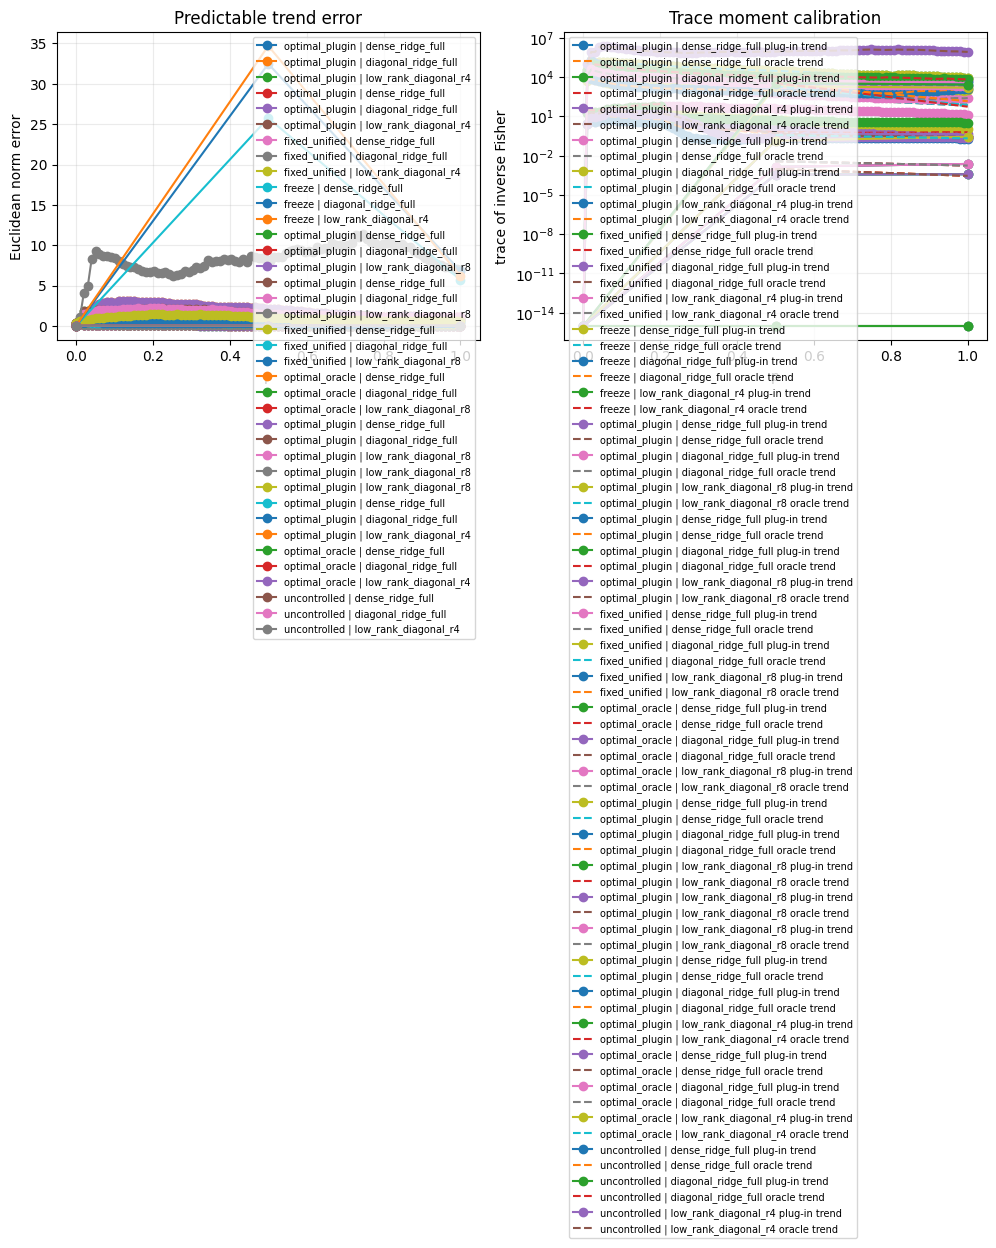

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (run_id, method), group in modern.groupby(['run_id', 'method']):
    ordered = group.sort_values('p')
    label = f"{ordered['policy'].iloc[0]} | {method}"
    axes[0].plot(ordered['p'], ordered['trend_oracle_norm_error'], marker='o', label=label)
    axes[1].plot(ordered['p'], ordered['controller_trace_estimate'].clip(lower=1e-15), marker='o', label=f'{label} plug-in trend')
    axes[1].plot(ordered['p'], ordered['controller_oracle_trace_estimate'].clip(lower=1e-15), linestyle='--', label=f'{label} oracle trend')
axes[0].set(title='Predictable trend error', xlabel='p', ylabel='Euclidean norm error')
axes[1].set(title='Trace moment calibration', xlabel='p', ylabel='trace of inverse Fisher')
axes[1].set_yscale('log')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=7)
plt.tight_layout()


## Curvature and residual diagnostics

In [ ]:
turning_rows = []
for run in phase8_runs:
    for row in run.metrics['oracle_path_checks']['turning']:
        turning_rows.append({'run_id': run.run_id, **row})
display(pd.DataFrame(turning_rows))
dependence_rows = []
for run in phase8_runs:
    for method, diagnostics in run.metrics.get('residual_dependence', {}).items():
        dependence_rows.append({'run_id': run.run_id, 'policy': run.metrics['policy'], 'method': method, **diagnostics})
if dependence_rows:
    display(pd.DataFrame(dependence_rows).drop(columns=['plugin_half_life_windows', 'oracle_half_life_windows']))

residual_columns = [
    'run_id', 'method', 'step', 'p', 'acceptance_gain',
    'acceptance_residual_norm', 'acceptance_scale_observation',
    'acceptance_residual_to_scale_ratio',
    'acceptance_oracle_residual_norm',
    'acceptance_oracle_residual_to_scale_ratio',
]
available = [column for column in residual_columns if column in flat.columns]
display(flat[available].dropna(subset=['acceptance_residual_norm'] if 'acceptance_residual_norm' in available else None))


,run_id,angle_radians,cosine,second_difference_norm,step
0,mnist_lfu_phase8_controller_smoke__replica-000...,0.213484,0.977299,0.006532,1
1,mnist_lfu_phase8_controller_smoke__replica-000...,0.213484,0.977299,0.006532,1
2,mnist_lfu_phase8_convergence_smoke__replica-00...,0.350194,0.939306,0.010518,1
3,mnist_lfu_phase8_fixed_compatibility_smoke__re...,0.213484,0.977299,0.006532,1
4,mnist_lfu_phase8_fixed_compatibility_smoke__re...,0.213484,0.977299,0.006532,1
...,...,...,...,...,...
690,mnist_lfu_phase8_gpu_k50_plugin_rank8__replica...,0.498059,0.878512,0.008612,97
691,mnist_lfu_phase8_gpu_k50_plugin_rank8__replica...,0.500127,0.877522,0.035979,98
692,mnist_lfu_phase8_lbfgs_smoke__replica-0000__d6...,0.350194,0.939306,0.010518,1
693,mnist_lfu_phase8_oracle_smoke__replica-0000__f...,0.213484,0.977299,0.006532,1


,run_id,policy,method,half_life_window_steps,oracle_ratio_coefficient_of_variation,oracle_squared_norm_lag_one_correlation,oracle_vector_lag_one_correlation,plugin_ratio_coefficient_of_variation,plugin_squared_norm_lag_one_correlation,plugin_vector_lag_one_correlation,residual_count,trend_removed,residual_semantics
0,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,dense_ridge_full,2,0.305053,NaN,NaN,0.525578,NaN,NaN,2,True,NaN
1,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,diagonal_ridge_full,2,0.306877,NaN,NaN,0.522752,NaN,NaN,2,True,NaN
2,mnist_lfu_phase8_convergence_smoke__replica-00...,optimal_plugin,low_rank_diagonal_r4,2,0.306023,NaN,NaN,0.524711,NaN,NaN,2,True,NaN
3,mnist_lfu_phase8_gpu_convergence__replica-0000...,optimal_plugin,dense_ridge_full,20,4.176561,0.455628,0.711709,1.279050,0.769449,0.144173,99,True,NaN
4,mnist_lfu_phase8_gpu_convergence__replica-0000...,optimal_plugin,diagonal_ridge_full,20,3.715887,0.458671,0.719315,0.918034,0.627019,0.617781,99,True,NaN
5,mnist_lfu_phase8_gpu_convergence__replica-0000...,optimal_plugin,low_rank_diagonal_r8,20,4.125798,0.457725,0.705953,1.976182,0.665236,0.176695,99,True,NaN
6,mnist_lfu_phase8_gpu_corrected_plugin__replica...,optimal_plugin,dense_ridge_full,20,1.925955,0.960518,0.722327,1.849486,0.880232,0.561879,99,True,u_minus_pi_times_predictable_drift
7,mnist_lfu_phase8_gpu_corrected_plugin__replica...,optimal_plugin,diagonal_ridge_full,20,2.294674,0.865385,0.636197,1.941052,0.958650,0.914613,99,True,u_minus_pi_times_predictable_drift
8,mnist_lfu_phase8_gpu_corrected_plugin__replica...,optimal_plugin,low_rank_diagonal_r8,20,2.385917,0.953775,0.645293,2.629515,0.872377,0.558108,99,True,u_minus_pi_times_predictable_drift
9,mnist_lfu_phase8_gpu_k100_fixed__replica-0000_...,fixed_unified,dense_ridge_full,20,2.165750,0.923389,-0.030204,2.147342,0.924252,-0.038409,99,True,u_minus_pi_times_predictable_drift


,run_id,method,step,p,acceptance_gain,acceptance_residual_norm,acceptance_scale_observation,acceptance_residual_to_scale_ratio,acceptance_oracle_residual_norm,acceptance_oracle_residual_to_scale_ratio
0,mnist_lfu_phase8_controller_smoke__replica-000...,dense_ridge_full,0,0.0,0.823223,0.013132,0.001276,0.135153,0.021729,0.370026
1,mnist_lfu_phase8_controller_smoke__replica-000...,dense_ridge_full,1,0.5,0.823223,0.019407,0.001277,0.295024,0.015069,0.177867
3,mnist_lfu_phase8_controller_smoke__replica-000...,diagonal_ridge_full,0,0.0,0.823223,0.013176,0.001276,0.136052,0.021753,0.370814
4,mnist_lfu_phase8_controller_smoke__replica-000...,diagonal_ridge_full,1,0.5,0.823223,0.019426,0.001277,0.295614,0.015067,0.177828
6,mnist_lfu_phase8_controller_smoke__replica-000...,low_rank_diagonal_r4,0,0.0,0.823223,0.013159,0.001276,0.135690,0.021737,0.370273
...,...,...,...,...,...,...,...,...,...,...
1773,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,dense_ridge_full,1,0.5,0.823223,0.019529,1.000000,0.000381,0.015067,0.000227
1775,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,diagonal_ridge_full,0,0.0,0.823223,0.013298,0.510417,0.000346,0.021837,0.000934
1776,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,diagonal_ridge_full,1,0.5,0.823223,0.019529,1.000000,0.000381,0.015067,0.000227
1778,mnist_lfu_phase8_uncontrolled_smoke__replica-0...,low_rank_diagonal_r4,0,0.0,0.823223,0.013298,0.510417,0.000346,0.021837,0.000934
